In [1]:
# from LadrunoGraphStyle import set_default_plot_params, main_colors
# set_default_plot_params()

In [2]:
from fem import (
    # Core
    Material,
    # Sections
    Membrane,
    # Gmsh tools
    GMSHtools,
    # Model
    FEMModel,
    # Elements
    CST, LST, Quad4, Quad9,
    # Units
    kgf, tf, kN, MPa, GPa, kg, g, cm, m, mm, N,
    # Parameters
    globalParameters,
)


import os
import numpy as np
import matplotlib.pyplot as plt
import gmsh
np.set_printoptions(suppress=True, precision=6, linewidth=400)


  FEM -- Finite Element Method for Structural Analysis
  Based on the course by Prof. Jose Abell

  Version 1.2.0                        (c) 2026 All Rights Reserved

  Repository  :  https://github.com/ppalacios92/FEM
  Web Book    :  https://books.nmorabowen.com/books/fem

  Patricio Palacios B.    |    Nicolas Mora Bowen
  
  ********* (>'-')> Ladruno4ever  *********



In [3]:
globalParameters['nDoF'] = 2
globalParameters['nDIM'] = 2

In [4]:
# General model parameters

output_path = os.getcwd()
mesh_name = 'batman'
output_file = os.path.join(output_path, mesh_name + '.msh')

if not os.path.exists(output_path):
    os.makedirs(output_path)

In [5]:
# Material
Steel=Material( name='Steel',
                E=2000,
                nu=0.30,
                rho=1.25*tf/m**3*0)

# Sections
F1=Membrane(    name='F1',
                thickness=15,
                material=Steel)

# Dictionaries
section_dictionary={17:F1,
                        }

restrain_dictionary={18:['r', 'f']}

load_dictionary = {
                19:   {'value': 10, 'direction': 'x'},   
                20:   {'value': 10, 'direction': '-x'},   

}

In [6]:
# read mesh 
mesh = GMSHtools(output_file)

  MESH SUMMARY

  === NODES ===  (2681 total — showing first 3)
     Tag              x              y              z
--------------------------------------------------------------------------------
       1        -1.0000         1.0000         0.0000
       2        -0.7500         3.0000         0.0000
       3        -0.5000         2.2500         0.0000
--------------------------------------------------------------------------------

  === PHYSICAL GROUPS ===  (4 total)
      ID    Dim   Name
--------------------------------------------------------------------------------
      18      0   'support'
      19      1   'load_p_x'
      20      1   'load_m_x'
      17      2   'steel'
--------------------------------------------------------------------------------

  === ELEMENTS ===  (4 groups)
      ID    Dim     Type   Nodes/el   N elements   Name
--------------------------------------------------------------------------------
      18      0       15          1            2   'su

In [7]:
# Map number of nodes per element to element class
element_map = {
    3: CST,         # 3-node triangles
    4: Quad4,       # 4-node quadrilaterals
    6: LST,         # 6-node triangles
    9: Quad9,       # 9-node quadrilaterals
}

# Build FEM model — applies BCs, builds elements, assembles load vector
model = FEMModel(
    mesh                = mesh,
    section_dictionary  = section_dictionary,
    restrain_dictionary = restrain_dictionary,
    load_dictionary     = load_dictionary,
    element_class_map   = element_map,
    analysis_type       = 'planeStress',
    consistent_loads    = True,
    sampling_points     = 3,

    verbose=True,
)


  FEM MODEL SUMMARY
--------------------------------------------------------------------------------
  Analysis type    : planeStress
  Nodes            : 2681
  system_nDof      : 5362
  Elements         : 5068
  Steps FEM        : 0
  Steps OpenSees   : 0

  --- Sections ---
  [17] steel                 t=15  E=2000.00  nu=0.300

  --- Restrained nodes ---
  Node      4  [0.   2.25]                     ['r', 'f']
  Node      9  [ 0. -3.]                       ['r', 'f']

  --- Loaded nodes (dim=0) ---

  --- Load vector ---
  Non-zero DOFs in F_load : 104
  Total applied force     : -0.0000 (x)  0.0000 (y)
--------------------------------------------------------------------------------



In [8]:
# Mesh diagnostics
model.check_mesh()


  MESH DIAGNOSTICS
--------------------------------------------------------------------------------
  Nodes            : 2681
  system_nDof      : 5362
  Elements         : 5068
  Physical groups  : 4

  --- Orphan nodes ---
  OK — no orphan nodes

  --- Physical groups ---
      ID   Dim  Name                    Elements     Nodes  Section
  ------  ----  --------------------  ----------  --------  ----------
      18     0  support                        2         2  N/A
      19     1  load_p_x                      51        52  N/A
      20     1  load_m_x                      51        52  N/A
      17     2  steel                       5068      2681  OK

  --- Restrained nodes ---
     Tag             x             y  Condition
  ------  ------------  ------------  ------------
       4        0.0000        2.2500  ['r', 'f']
       9        0.0000       -3.0000  ['r', 'f']

  --- Load summary ---
  Non-zero DOFs    : 104
  Total Fx         : -0.0000
  Total Fy         : +0.000

In [9]:
# Solve — single step
model.solve_static(
    n_steps=1, 
    load_factor=1.0,
    verbose = True,
)


  SOLVE SUMMARY
--------------------------------------------------------------------------------
  Steps solved     : 1
  Last load factor : 1.0000
  Max |ux|         : 0.289338
  Max |uy|         : 0.183320
  Max Von Mises    : 148.7704

  --- Equilibrium ---
  Applied  Fx: -0.0000   Reaction Rx: -0.0000   Balance: -2.0555e-10
  Applied  Fy: +0.0000   Reaction Ry: +0.0000   Balance: 0.0000e+00
--------------------------------------------------------------------------------



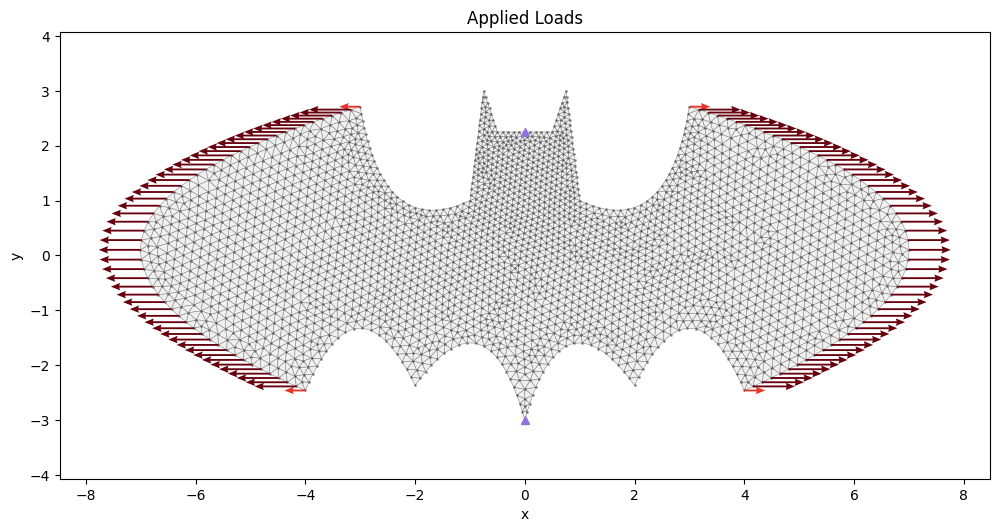

In [10]:
# Plot loads
model.plot_loads(
    show_element_edges = True,
    show_node_points   = True,
    show_supports      = True,
    figsize            = (12, 8),
)

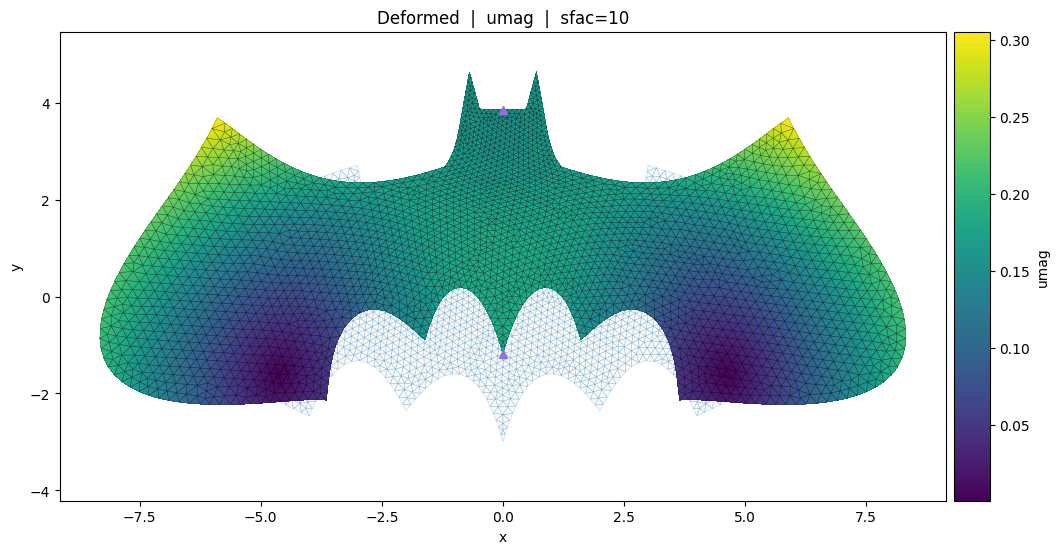

In [17]:
# Plot deformed
model.plot_deformed(
    sfac                = 10,
    step                = -1,
    component           = 'umag',   # 'ux', 'uy', 'umag'
    cmap                = 'viridis',
    show_element_edges  = True,
    show_supports       = True,
    figsize             = (12, 8),
)

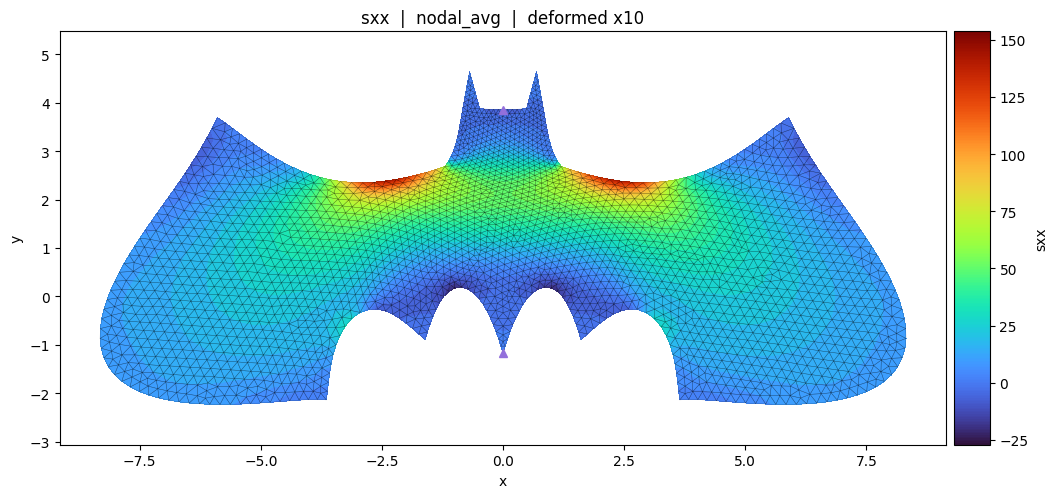

In [16]:
# Plot field
model.plot_field(
    component           = 'sxx',        # 'sxx','syy','sxy','vmis','s1','s2','exx','eyy','exy'
    source              = 'fem',
    step                = -1,
    result_type         = 'nodal_avg',  # 'nodal_avg' or 'element'
    deformed            = True,
    sfac                = 10,
    cmap                = 'turbo',
    show_element_edges  = True,
    show_supports       = True,
    figsize             = (12, 8),
)

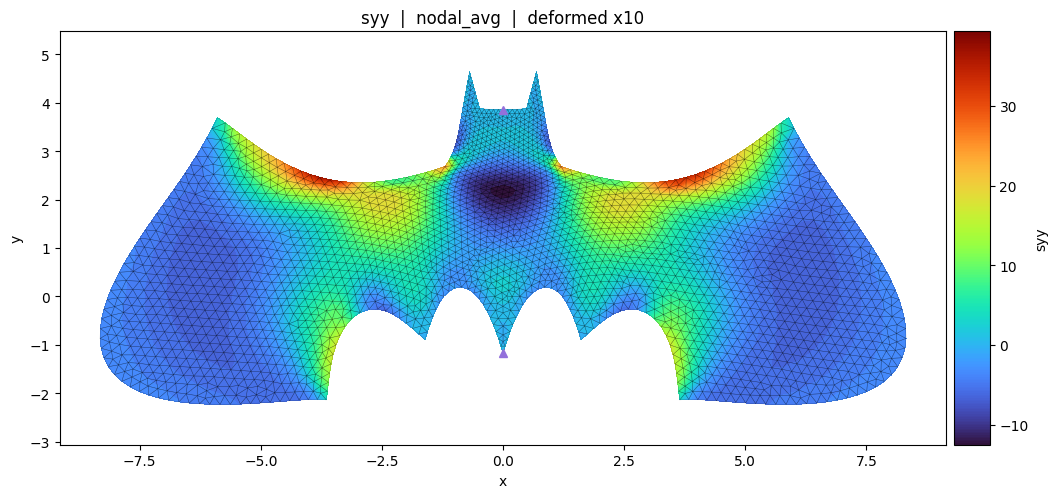

In [15]:
# Plot field
model.plot_field(
    component           = 'syy',        # 'sxx','syy','sxy','vmis','s1','s2','exx','eyy','exy'
    source              = 'fem',
    step                = -1,
    result_type         = 'nodal_avg',  # 'nodal_avg' or 'element'
    deformed            = True,
    sfac                = 10,
    cmap                = 'turbo',
    show_element_edges  = True,
    show_supports       = True,
    figsize             = (12, 8),
)